In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/processed/cleaned_data.csv')

In [3]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [4]:
df['Sales'] = df['Quantity'] * df['UnitPrice']

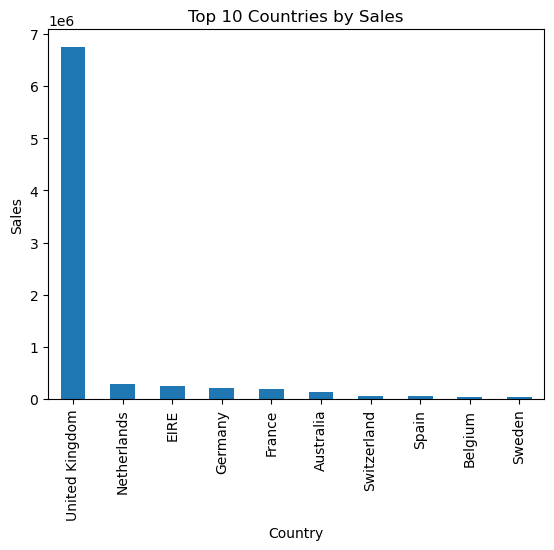

In [5]:
country_sales = df.groupby('Country')['Sales'].sum().sort_values(ascending=False)

plt.figure()
country_sales.head(10).plot(kind='bar')
plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Sales")
plt.show()

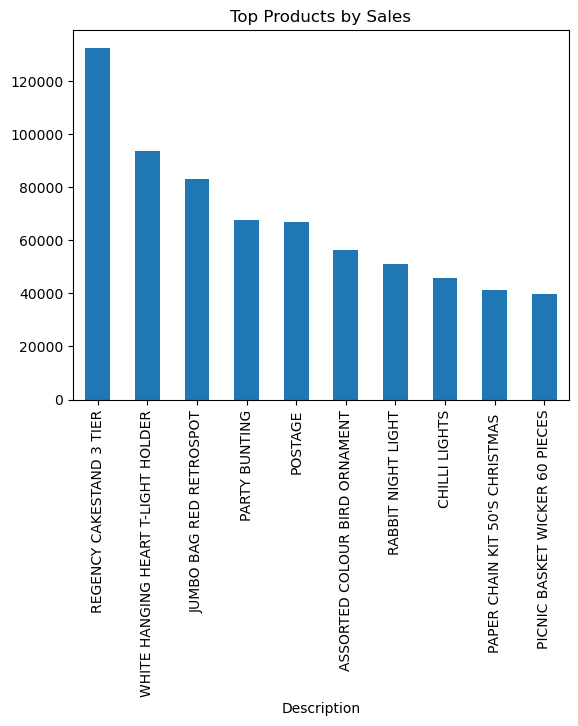

In [7]:
top_products = df.groupby('Description')['Sales'].sum().sort_values(ascending=False)

plt.figure()
top_products.head(10).plot(kind='bar')
plt.title("Top Products by Sales")
plt.xticks(rotation=90)
plt.show()

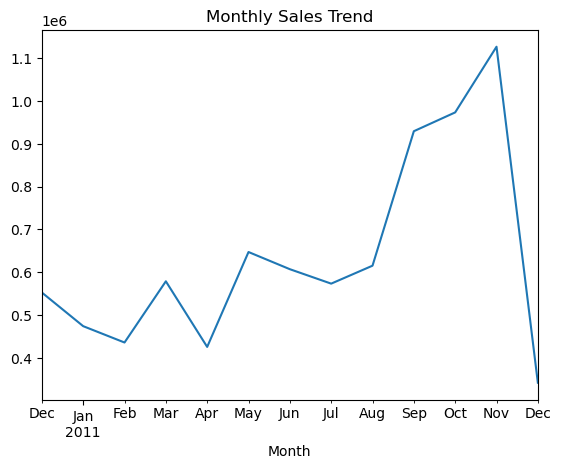

In [6]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()

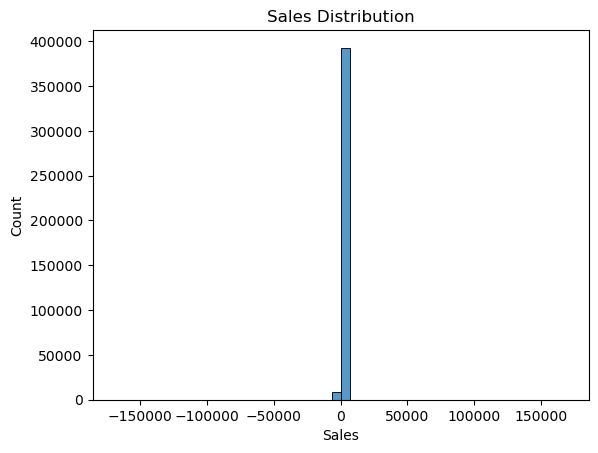

In [8]:
plt.figure()
sns.histplot(df['Sales'], bins=50)
plt.title("Sales Distribution")
plt.show()

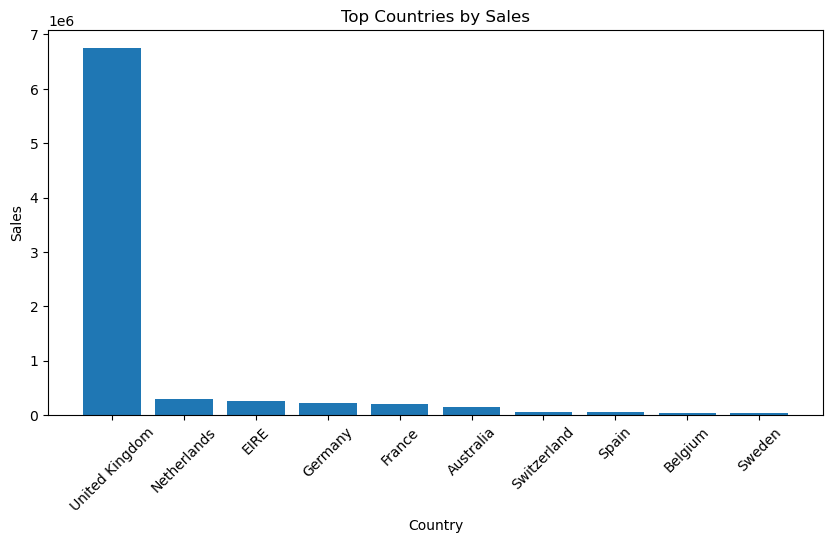

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load data
df = pd.read_csv('../data/processed/cleaned_data.csv')

# Create Sales column
df['Sales'] = df['Quantity'] * df['UnitPrice']

# Group data
country_sales = df.groupby('Country')['Sales'].sum().sort_values(ascending=False)

# Create reports folder
os.makedirs('../reports', exist_ok=True)

# 🔥 IMPORTANT: Create figure FIRST
plt.figure(figsize=(10,5))

# Plot
plt.bar(country_sales.head(10).index, country_sales.head(10).values)

plt.title("Top Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Sales")

plt.xticks(rotation=45)

# 🔥 SAVE AFTER PLOT
plt.savefig('../reports/country_sales.png')

# SHOW
plt.show()